## **Pharmaceutical EDA**

### **Importing Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pharm = pd.read_csv('/Users/marlen/Data_Analysis/Datasets/pharmaceutical.csv')

In [3]:
pharm.head()

,LOCATION,TIME,PC_HEALTHXP,PC_GDP,USD_CAP,TOTAL_SPEND
0,AUS,1971,15.992,0.726,33.990,439.73
1,AUS,1972,15.091,0.685,34.184,450.44
2,AUS,1973,15.117,0.681,37.956,507.85
3,AUS,1974,14.771,0.754,45.338,622.17
4,AUS,1975,11.849,0.682,44.363,616.34


In [5]:
pharm.shape

(1341, 6)

In [6]:
# Obtaining dataframe summary
pharm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1341 entries, 0 to 1340
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LOCATION     1341 non-null   object 
 1   TIME         1341 non-null   int64  
 2   PC_HEALTHXP  1341 non-null   float64
 3   PC_GDP       1341 non-null   float64
 4   USD_CAP      1341 non-null   float64
 5   TOTAL_SPEND  1341 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 63.0+ KB


In [7]:
# Checking for any duplicates
pharm.duplicated().sum()

0

In [8]:
pharm

,LOCATION,TIME,PC_HEALTHXP,PC_GDP,USD_CAP,TOTAL_SPEND
0,AUS,1971,15.992,0.726,33.990,439.73
1,AUS,1972,15.091,0.685,34.184,450.44
2,AUS,1973,15.117,0.681,37.956,507.85
3,AUS,1974,14.771,0.754,45.338,622.17
4,AUS,1975,11.849,0.682,44.363,616.34
...,...,...,...,...,...,...
1336,USA,2017,11.954,2.004,1200.769,390396.57
1337,USA,2018,11.766,1.957,1229.266,401771.09
1338,USA,2019,11.767,1.961,1277.032,419287.86
1339,USA,2020,11.037,2.070,1315.218,436030.19


In [9]:
# Obtaining statistical information on quantitative columns
pharm.describe()

,TIME,PC_HEALTHXP,PC_GDP,USD_CAP,TOTAL_SPEND
count,1341.000000,1341.000000,1341.000000,1341.000000,1341.000000
mean,2001.134228,16.632877,1.215524,338.278398,14439.322088
std,14.093659,6.613320,0.479568,226.158326,43259.358895
min,1970.000000,5.545000,0.207000,3.628000,5.810000
25%,1990.000000,11.849000,0.802000,144.592000,756.280000
50%,2004.000000,15.238000,1.187000,317.795000,2786.190000
75%,2013.000000,20.580000,1.524000,496.858000,8794.360000
max,2022.000000,40.239000,2.870000,1432.309000,475596.740000


In [10]:
# Summary of object column
pharm.describe(include='object')

,LOCATION
count,1341
unique,44
top,CAN
freq,53


In [15]:
# Checking amount of unique values in each column
for column in pharm.columns:
    unique = pharm[column].nunique()
    print(column + ": " + str(unique))

LOCATION: 44
TIME: 53
PC_HEALTHXP: 1304
PC_GDP: 906
USD_CAP: 1339
TOTAL_SPEND: 1340


In [21]:
pharm['LOCATION'].unique()

array(['AUS', 'AUT', 'BEL', 'BGR', 'BRA', 'CAN', 'CHE', 'CHL', 'COL',
       'CRI', 'CYP', 'CZE', 'DEU', 'DNK', 'ESP', 'EST', 'FIN', 'FRA',
       'GBR', 'GRC', 'HRV', 'HUN', 'IRL', 'ISL', 'ISR', 'ITA', 'JPN',
       'KOR', 'LTU', 'LUX', 'LVA', 'MEX', 'MLT', 'NLD', 'NOR', 'NZL',
       'POL', 'PRT', 'ROU', 'SVK', 'SVN', 'SWE', 'TUR', 'USA'],
      dtype=object)

### **How has pharmaceutical spending changed over time in specific countries?**

In [16]:
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [23]:
def country_trends(countries, column='USD_CAP'):
    plt.figure()
    for country in countries:
        data = pharm[pharm['LOCATION'] == country]
        plt.plot(data['TIME'], data[column], label=country)
    plt.title(f'{column} Over Time')
    plt.xlabel('Year')
    plt.ylabel(column)
    plt.legend()
    plt.show()

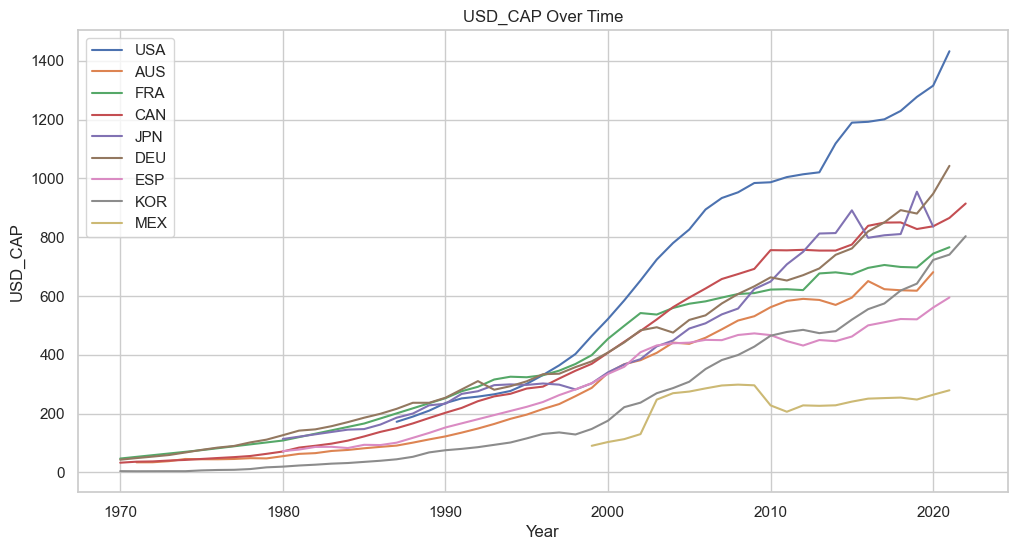

In [28]:
# Choosing specific countries to observe time trend
country_trends(['USA', 
                'AUS', 
                'FRA', 
                'CAN', 
                'JPN', 
                'DEU', 
                'ESP', 
                'KOR',
                'MEX'], column='USD_CAP')

### **Which countries have the fastest growth in pharmaceutical spending?**

In [68]:
# Plotting top 10 countries with fastest growth in spending

def fastest_growth(column='USD_CAP', top_n=10):
    growth = pharm.sort_values('TIME').groupby('LOCATION')[column].agg(['first', 'last'])
    growth['growth_rate'] = (growth['last'] - growth['first']) / growth['first']
    top_growth = growth.sort_values('growth_rate', ascending=False).head(top_n)
    sns.barplot(x=top_growth.index, y=top_growth['growth_rate'], palette='viridis', legend=False)
    plt.title(f'Top {top_n} Countries by Growth Rate in {column}')
    plt.ylabel('Growth Rate')
    plt.xticks(rotation=45)
    plt.show()

/var/folders/65/0yqlcf2x2ds08ltztt0hx_m80000gn/T/ipykernel_3474/3991761675.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_growth.index, y=top_growth['growth_rate'], palette='viridis', legend=False)


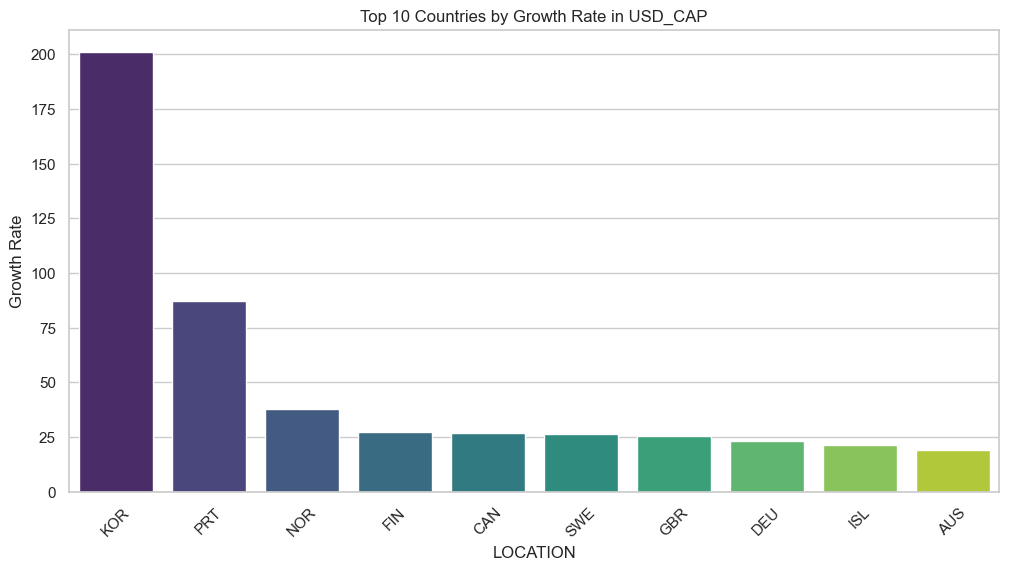

In [69]:
fastest_growth()

### **Which countries consistently spend the most on pharmaceuticals per capita?**

In [48]:
# Plotting top 10 countries that spend the most on pharmaceuticals per capita in the year 2022

def top_countries(column='USD_CAP', top_n=10):
    latest_year = pharm['TIME'].max()
    recent = pharm[pharm['TIME'] == latest_year]
    top = recent.nlargest(top_n, column)
    
    sns.barplot(x='LOCATION', y=column, data=top)
    plt.title(f'Top {top_n} in {column} ({latest_year})')

    
    plt.tight_layout()
    plt.show()

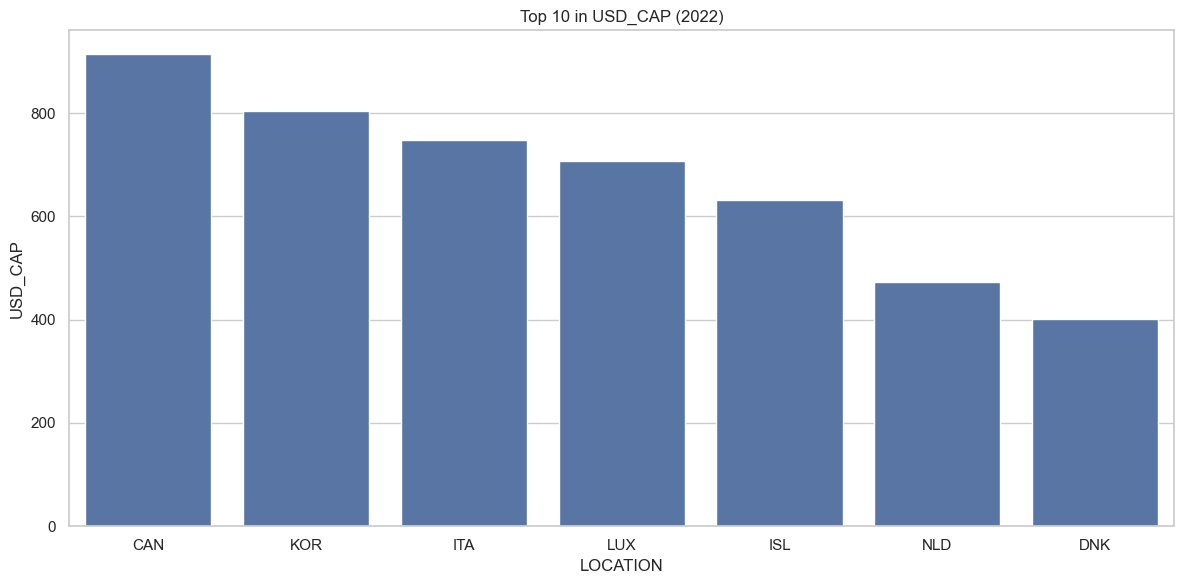

In [49]:
top_countries()

### **Are wealthier countries spending more on pharmaceuticals?**

In [62]:
# Finding correlation between PC_GDP and USD_CAP

def correlation(x_col, y_col):
    sns.scatterplot(data=pharm, x=x_col, y=y_col, hue='LOCATION', legend=False)
    corr = pharm[[x_col, y_col]].corr().iloc[0, 1]
    plt.title(f'{x_col} vs {y_col} (Correlation: {corr:.2f})')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()


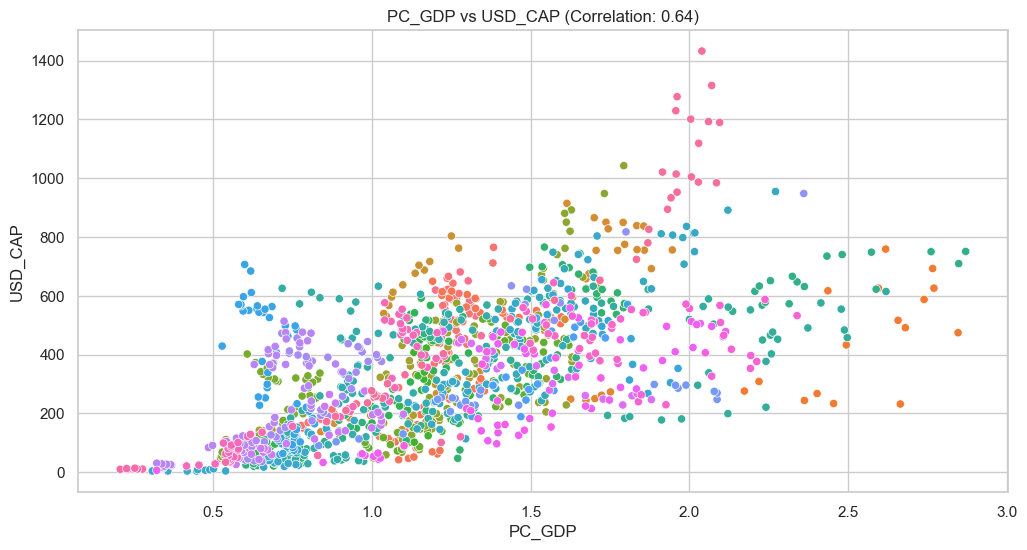

In [63]:
correlation('PC_GDP', 'USD_CAP')

### **Is there a strong correlation between total spend and capita spend?**

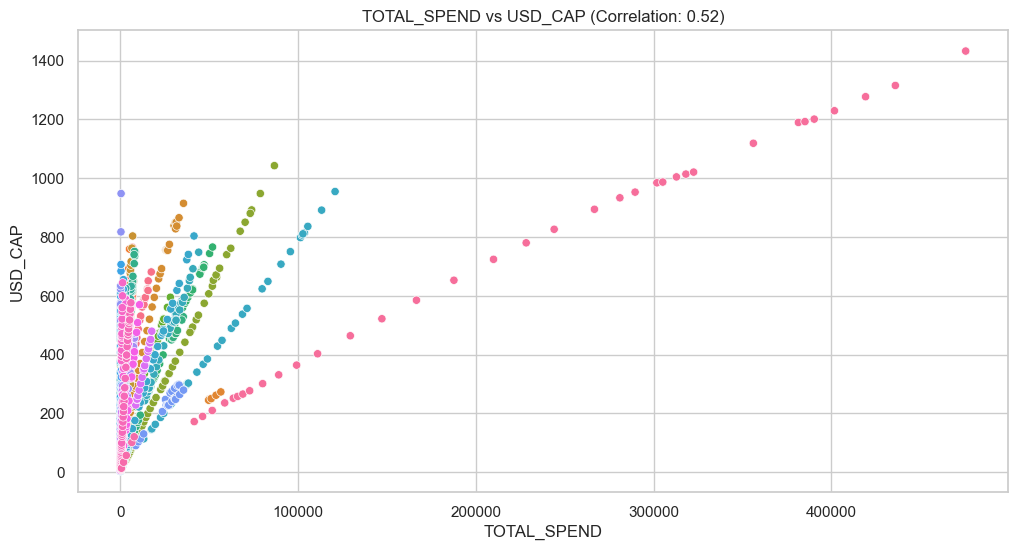

In [64]:
correlation('TOTAL_SPEND', 'USD_CAP')